# Backward Thiele vs Backward Kolmogorov

A side-by-side comparison in the context of the survival model from the Liv2 course.

## Setup

We consider the survival model (alive/dead) with mortality rate from mortality.csv.

| Equation | What it computes | Terminal/boundary condition |
|----------|-----------------|---------------------------|
| **Backward Kolmogorov** | Transition probabilities p(t,s) | p(s,s) = 1 |
| **Backward Thiele** | Reserves V_tilde_0(t) | V_tilde_0(T) = 0 |

Both are solved **backward in time** (from a future boundary toward the present), but they describe fundamentally different quantities.

## 1. Backward Kolmogorov Equation

For the survival model, the **survival probability** from age t to age s satisfies:

$$\\frac{\\partial}{\\partial t} \\, p_{00}(t, s) = \\mu(t) \\, p_{00}(t, s), \\qquad p_{00}(s, s) = 1.$$

**Interpretation:** How does the probability of surviving from t to s change as we vary the starting time t?

- This is purely about **transition probabilities** (no money, no discounting).
- The equation says: moving the start time t earlier by dt means you must also survive the interval [t, t+dt), which happens with probability 1 - mu(t) dt.
- Solution: $p_{00}(t, s) = \\exp\\left(\\int_t^s \\mu(v)\\,dv\\right)$, so the survival probability is $\\exp\\left(-\\int_t^s \\mu(v)\\,dv\\right)$.

## 2. Backward Thiele Equation

For a **life annuity** paying 1 per unit time while alive, valued on basis $(\\tilde{r}, \\tilde{\\mu})$:

$$\\frac{d}{dt} \\tilde{V}_0(t) = \\big(\\tilde{r}(t) + \\tilde{\\mu}(t)\\big)\\,\\tilde{V}_0(t) - 1, \\qquad \\tilde{V}_0(T) = 0.$$

**Interpretation:** How does the **reserve** (expected present value of future benefits) change as we move backward in time?

- This is about **money**: discounting ($\\tilde{r}$), mortality ($\\tilde{\\mu}$), and cash flows ($-1$ for the annuity payment).
- The $\\tilde{r}(t)\\,\\tilde{V}_0(t)$ term: interest earned on the reserve.
- The $\\tilde{\\mu}(t)\\,\\tilde{V}_0(t)$ term: mortality credit - if the insured dies, the reserve is released.
- The $-1$ term: the continuous annuity payment of 1 per unit time.

## 3. Key Differences

| Aspect | Backward Kolmogorov | Backward Thiele |
|--------|-------------------|-----------------|
| **Output** | Probability $p_{00}(t,s)$ | Reserve $\\tilde{V}_0(t)$ (monetary value) |
| **Driving terms** | Mortality $\\mu$ only | Mortality $\\tilde{\\mu}$ + interest $\\tilde{r}$ + cash flows |
| **Homogeneous?** | Yes (no forcing term) | No (the $-1$ annuity payment is a forcing term) |
| **Why backward?** | Terminal condition at $s$ | Terminal condition at $T$: no future obligations remain |
| **Connection** | Describes the probability kernel | Uses the probability kernel to weight future cash flows |

**The relationship:** Thiele *builds on* Kolmogorov. The reserve formula involves survival probabilities (from Kolmogorov) combined with discounting and cash flows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Load mortality data (semicolon-separated, comma decimals)
mort = pd.read_csv('/workspace/mortality.csv', sep=';', decimal=',')
mu_data = mort['Intensity'].values
ages = mort['Age'].values
mu_func = interp1d(ages, mu_data, kind='linear', fill_value='extrapolate')

# Parameters
r = 0.02
alpha = 0.04
sigma = 0.13
m = 70
T = 111

def pi_func(t):
    if t < 55:
        return 1.0
    elif t <= m:
        return -1/(2*(m-55)) * t + (2*m - 55)/(2*(m-55))
    else:
        return 0.5

def r_tilde(t):
    return pi_func(t) * alpha + (1 - pi_func(t)) * r

def mu_tilde(t):
    return float(mu_func(t))

print('Data loaded. Age range:', ages[0], 'to', ages[-1])
print(f'mu(30) = {mu_func(30):.6f}, mu(70) = {mu_func(70):.6f}, mu(100) = {mu_func(100):.6f}')

Data loaded. Age range: 0 to 110
mu(30) = 0.000327, mu(70) = 0.017025, mu(100) = 0.477853


## 4. Numerical Solutions

In [2]:
# --- Backward Kolmogorov ---
# Solve: d/dt p(t, T) = mu(t) * p(t, T),  p(T, T) = 1
# Solution: p(t,T) = exp(int_t^T mu(v) dv)
# Survival probability = 1/p(t,T) = exp(-int_t^T mu(v) dv)

h = 1/1000
t_grid = np.arange(30, T, h)
N = len(t_grid)

p_kolmo = np.zeros(N)
p_kolmo[-1] = 1.0

for i in range(N - 2, -1, -1):
    t = t_grid[i]
    p_kolmo[i] = p_kolmo[i+1] * (1 + float(mu_func(t)) * h)

surv_prob = 1.0 / p_kolmo

print(f'Survival prob from 30 to 111: {surv_prob[0]:.6e}')
print(f'Survival prob from 70 to 111: {surv_prob[np.searchsorted(t_grid, 70)]:.6e}')
print(f'Survival prob from 100 to 111: {surv_prob[np.searchsorted(t_grid, 100)]:.6e}')

Survival prob from 30 to 111: 7.428069e-06
Survival prob from 70 to 111: 8.723933e-06
Survival prob from 100 to 111: 6.409456e-04


In [3]:
# --- Backward Thiele ---
# Solve: d/dt V(t) = (r_tilde(t) + mu_tilde(t)) * V(t) - 1,  V(T) = 0

V_thiele = np.zeros(N)
V_thiele[-1] = 0.0

for i in range(N - 2, -1, -1):
    t = t_grid[i]
    rt = r_tilde(t)
    mt = mu_tilde(t)
    V_thiele[i] = V_thiele[i+1] - h * ((rt + mt) * V_thiele[i+1] - 1)

idx_m = np.searchsorted(t_grid, m)
print(f'V_tilde(30) = {V_thiele[0]:.4f}')
print(f'V_tilde(70) = {V_thiele[idx_m]:.4f}  (reserve at retirement)')
print(f'V_tilde(90) = {V_thiele[np.searchsorted(t_grid, 90)]:.4f}')

V_tilde(30) = 21.8142
V_tilde(70) = 11.8700  (reserve at retirement)
V_tilde(90) = 3.6162


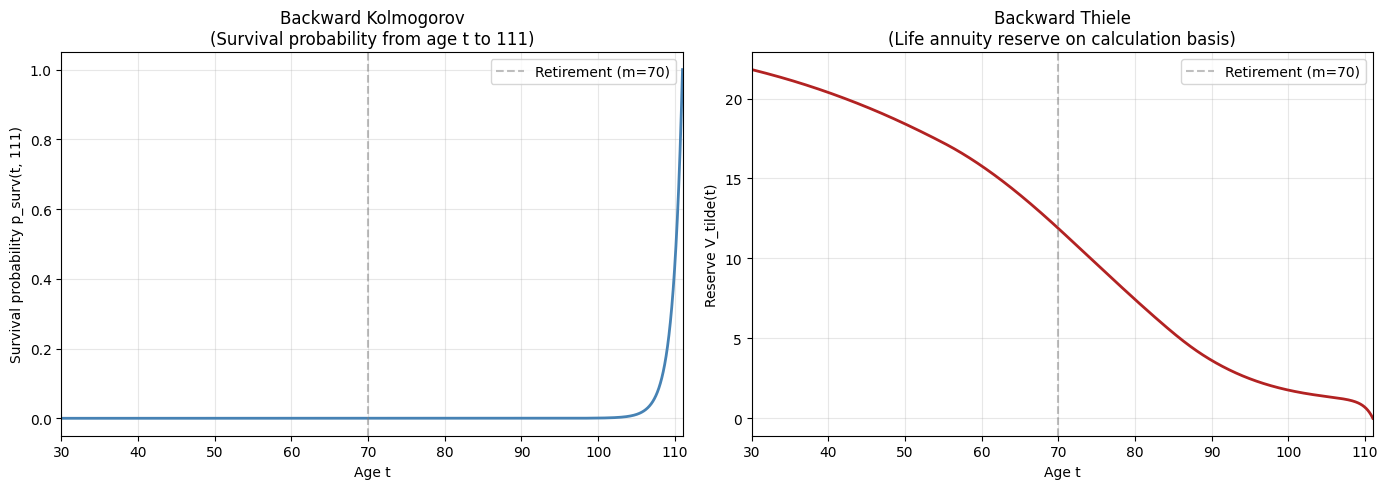

Plot saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Backward Kolmogorov - Survival probabilities
ax = axes[0]
ax.plot(t_grid, surv_prob, color='steelblue', linewidth=2)
ax.set_xlabel('Age t')
ax.set_ylabel('Survival probability p_surv(t, 111)')
ax.set_title('Backward Kolmogorov\n(Survival probability from age t to 111)')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5, label='Retirement (m=70)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(30, 111)

# Plot 2: Backward Thiele - Reserve
ax = axes[1]
ax.plot(t_grid, V_thiele, color='firebrick', linewidth=2)
ax.set_xlabel('Age t')
ax.set_ylabel('Reserve V_tilde(t)')
ax.set_title('Backward Thiele\n(Life annuity reserve on calculation basis)')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5, label='Retirement (m=70)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(30, 111)

plt.tight_layout()
plt.savefig('/workspace/helper/thiele_vs_kolmogorov.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

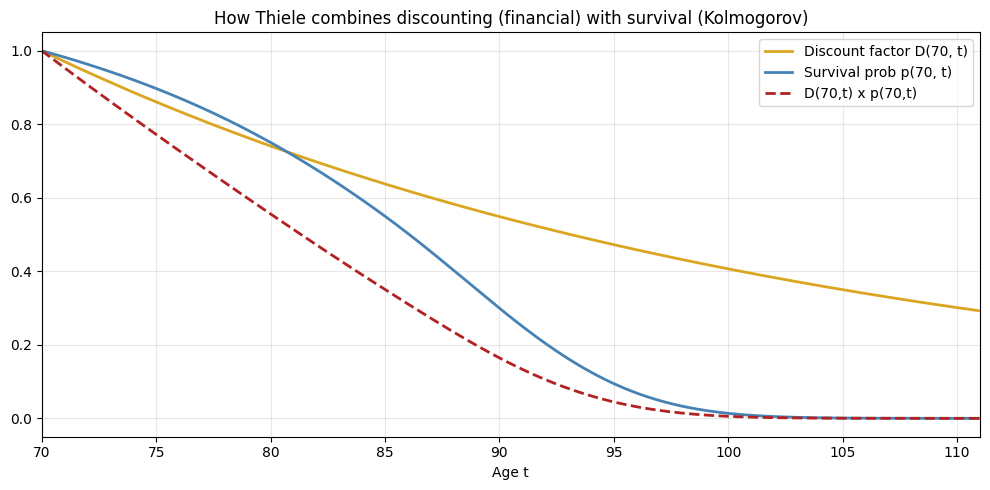

The reserve V_tilde(70) is the integral of the red dashed curve from 70 to 111.
Thiele = Kolmogorov (survival) + discounting (finance) + cash flows.


In [5]:
# --- Show the connection ---
# V(t) = integral from t to T of exp(-integral_t^s (r_tilde + mu_tilde) dv) ds
# The exponential factors as: D(t,s) * p_surv(t,s)
# D(t,s) = exp(-int_t^s r_tilde dv) is the discount factor
# p_surv(t,s) = exp(-int_t^s mu_tilde dv) is the survival probability

t_post = t_grid[idx_m:]
N_post = len(t_post)

d_from_70 = np.ones(N_post)
s_from_70 = np.ones(N_post)

for i in range(1, N_post):
    t = t_post[i-1]
    d_from_70[i] = d_from_70[i-1] * np.exp(-r_tilde(t) * h)
    s_from_70[i] = s_from_70[i-1] * np.exp(-mu_tilde(t) * h)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_post, d_from_70, label='Discount factor D(70, t)', color='goldenrod', linewidth=2)
ax.plot(t_post, s_from_70, label='Survival prob p(70, t)', color='steelblue', linewidth=2)
ax.plot(t_post, d_from_70 * s_from_70, label='D(70,t) x p(70,t)',
        color='firebrick', linewidth=2, linestyle='--')
ax.set_xlabel('Age t')
ax.set_title('How Thiele combines discounting (financial) with survival (Kolmogorov)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(70, 111)
plt.tight_layout()
plt.savefig('/workspace/helper/connection_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('The reserve V_tilde(70) is the integral of the red dashed curve from 70 to 111.')
print('Thiele = Kolmogorov (survival) + discounting (finance) + cash flows.')

## 5. Summary

- **Backward Kolmogorov** answers: *What is the probability of being in state j at time s, given state i at time t?* It only involves transition rates (mortality). No money.

- **Backward Thiele** answers: *What is the expected present value of all future cash flows, given I am alive at time t?* It combines:
  1. Survival probabilities (from Kolmogorov)
  2. Discounting at rate $\\tilde{r}$
  3. Cash flow structure (the $-1$ annuity payment)

- Both are solved **backward** because they have **terminal conditions** (known state/value at the end).

- **Thiele builds on Kolmogorov**: the reserve formula $\\tilde{V}_0(t) = \\int_t^T e^{-\\int_t^s (\\tilde{r} + \\tilde{\\mu})\\,dv}\\,ds$ factorises the exponential into a discount factor times a survival probability. The survival probability is exactly what Kolmogorov computes.